In [1]:
!pip install pandas scipy

import pandas as pd
from scipy.io import arff
import numpy as np
import os;

# Define the path to your ARFF file
file_path = os.path.join('/kaggle/input/datasets/tarekyahia/credit-g', 'dataset_31_credit-g.arff')

# 1. Load the ARFF data
df, meta = arff.loadarff(file_path)

# 2. Convert the structured array to a Pandas DataFrame
data = pd.DataFrame(df)

object_cols = data.select_dtypes(include=['object']).columns
for col in object_cols:
    # Use .apply() with a lambda function for robust decoding.
    # It checks if the value is a byte string (isinstance(x, bytes)) and decodes it using 'utf-8'.
    # Otherwise, it returns the value as is.
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [2]:
# 1. Credit amount per month
data['credit_per_month'] = data['credit_amount'] / data['duration']

#2. Credit amount per dependent
data['credit_per_dependent'] = data['credit_amount'] / (data['num_dependents'] + 1)

#3. Employment stability score
employment_mapping = {
    'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4
}

data['employment_stability_score'] = data['employment'].map(employment_mapping)

#4. Savings strength score
savings_mapping = {
    'no known savings': 0,
    '<100': 1,
    '100<=X<500': 2,
    '500<=X<1000': 3,
    '>=1000': 4
}

data['savings_strength_score'] = data['savings_status'].map(savings_mapping)

#5. Bad Credit History
bad_history_categories = ["critical/other existing credit", "delayed previously"]

data['bad_history'] = data['credit_history'].isin(bad_history_categories).astype(int)

#6. Job stability score
job_mapping = {
    'unemp/unskilled non res': 0,
    'unskilled resident': 1,
    'skilled': 2,
    'high qualif/self emp/mgmt': 3
}

data['job_stability_score'] = data['job'].map(job_mapping)

#7. Credit pressure ratio
#duration_installment_product = data['duration'] * data['installment_commitment']
data['credit_pressure_ratio'] = data['credit_amount'] / (data['duration'] * data['installment_commitment'])

#8. Credit per credit account
data['credit_per_credit_account'] = data['credit_amount'] / data['existing_credits']

data = data.drop(columns=[
    'employment',
    'savings_status', 
    'job'
])

#9 Liquidity vs. Liability. compare savings (liquidity) to the loan size (liability).
data['liquidity_ratio'] = data['savings_strength_score'] / (data['credit_amount'] + 1)

In [3]:
from sklearn.model_selection import train_test_split
X = data.drop('class', axis=1)
y = data['class'].map({'bad': 1, 'good': 0})

# Perform a stratified train-test split to ensure both sets have the same fraud ratio (0.17%)
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [4]:
# Numerical features: columns with numeric dtype
numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()

# Categorical features: columns with object or category dtype
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_features)}): {numerical_features}\n')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numerical features (12): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'credit_per_month', 'credit_per_dependent', 'credit_pressure_ratio', 'credit_per_credit_account', 'liquidity_ratio']

Categorical features (10): ['checking_status', 'credit_history', 'purpose', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'own_telephone', 'foreign_worker']


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Numerical pipeline: only scaling
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: only one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [6]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
 

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)
    print("classification_report:\n",classification_report(y_true, y_pred_class))

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results
final_results = []

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
    ))
])

lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Logistic Regression","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[142  68]
 [ 23  67]]
classification_report:
               precision    recall  f1-score   support

           0       0.86      0.68      0.76       210
           1       0.50      0.74      0.60        90

    accuracy                           0.70       300
   macro avg       0.68      0.71      0.68       300
weighted avg       0.75      0.70      0.71       300

Model                   Logistic Regression
Method                        Class Weights
PR-AUC                             0.621282
ROC-AUC                            0.773016
Recall (Fraud)                     0.744444
Precision (Fraud)                  0.496296
F1-Score                           0.595556
True Positives (TP)                      67
False Negatives (FN)                     23
dtype: object


In [9]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
20                            cat__foreign_worker_yes     0.406824
3                             cat__checking_status_<0     0.350190
0                                       num__duration     0.325151
19                                  cat__housing_rent     0.187022
17          cat__property_magnitude_no known property     0.107106
1                           num__credit_per_dependent     0.003877
2                      num__credit_per_credit_account     0.000000
4                          cat__checking_status_>=200     0.000000
8                   cat__credit_history_existing paid     0.000000
11                                 cat__purpose_other     0.000000
7              cat__credit_history_delayed previously     0.000000
10                               cat__purpose_new car     0.000000
9                              cat__purpose_education     0.000000
14                              cat__purpose_used car     0.00

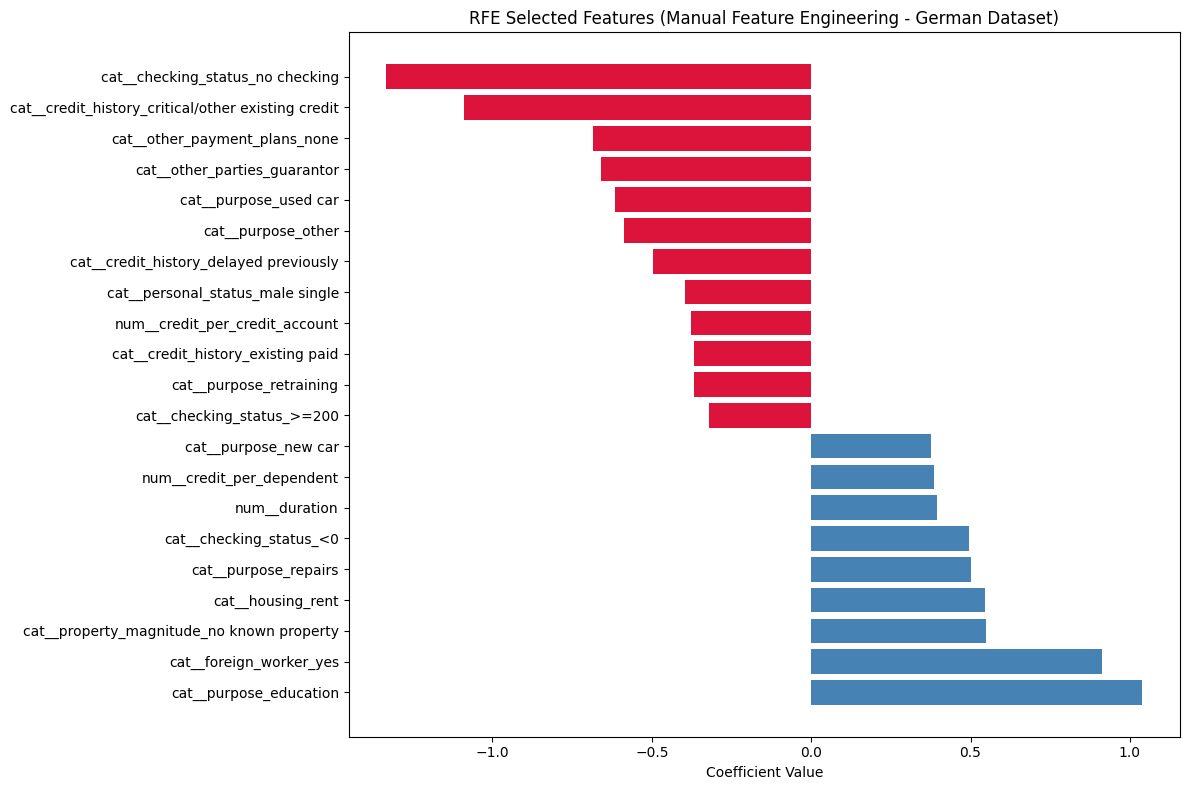

In [10]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#4682B4' if c > 0 else '#DC143C' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (Manual Feature Engineering - German Dataset)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.001,
        max_iter=1000,
        solver='liblinear',
        penalty='l2',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Logistic Regression", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[160  50]
 [ 27  63]]
classification_report:
               precision    recall  f1-score   support

           0       0.86      0.76      0.81       210
           1       0.56      0.70      0.62        90

    accuracy                           0.74       300
   macro avg       0.71      0.73      0.71       300
weighted avg       0.77      0.74      0.75       300

Model                   Logistic Regression
Method                                SMOTE
PR-AUC                             0.589835
ROC-AUC                            0.779418
Recall (Fraud)                          0.7
Precision (Fraud)                  0.557522
F1-Score                            0.62069
True Positives (TP)                      63
False Negatives (FN)                     27
dtype: object


In [12]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
0                                       num__duration     0.070434
4                             cat__checking_status_<0     0.064619
1                         num__installment_commitment     0.055521
2                           num__credit_per_dependent     0.032295
3                      num__credit_per_credit_account     0.026907
18                                  cat__housing_rent     0.020310
10                               cat__purpose_new car     0.014665
20                            cat__foreign_worker_yes     0.013469
9                              cat__purpose_education     0.011802
8             cat__credit_history_no credits/all paid     0.011158
12                            cat__purpose_retraining     0.000126
11                                 cat__purpose_other    -0.000261
17                    cat__other_payment_plans_stores    -0.001105
5                          cat__checking_status_>=200    -0.00

RF - CW

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=10,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "Random Forest","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[175  35]
 [ 41  49]]
classification_report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       210
           1       0.58      0.54      0.56        90

    accuracy                           0.75       300
   macro avg       0.70      0.69      0.69       300
weighted avg       0.74      0.75      0.74       300

Model                   Random Forest
Method                  Class Weights
PR-AUC                       0.619266
ROC-AUC                      0.789206
Recall (Fraud)               0.544444
Precision (Fraud)            0.583333
F1-Score                     0.563218
True Positives (TP)                49
False Negatives (FN)               41
dtype: object


In [14]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 12 out of 42 features.
num__credit_pressure_ratio          0.115383
num__credit_per_dependent           0.110728
num__credit_per_month               0.110197
num__credit_amount                  0.108902
num__liquidity_ratio                0.107805
num__credit_per_credit_account      0.098341
cat__checking_status_no checking    0.090887
num__age                            0.086103
num__duration                       0.079281
cat__checking_status_<0             0.037511
dtype: float64


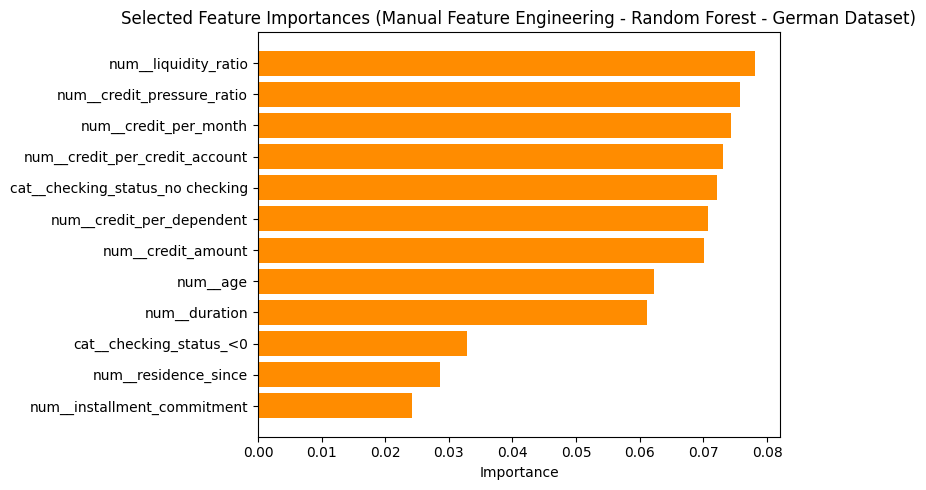

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#FF8C00'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (Manual Feature Engineering - Random Forest - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [16]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_features='log2',
        max_depth=20,
        criterion='entropy',
        n_jobs=-1,
        class_weight=None
    ))
]) 

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "Random Forest","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[174  36]
 [ 43  47]]
classification_report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       210
           1       0.57      0.52      0.54        90

    accuracy                           0.74       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.73      0.74      0.73       300

Model                   Random Forest
Method                          SMOTE
PR-AUC                       0.567376
ROC-AUC                      0.786085
Recall (Fraud)               0.522222
Precision (Fraud)            0.566265
F1-Score                     0.543353
True Positives (TP)                47
False Negatives (FN)               43
dtype: object


In [17]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 15 out of 42 features.
cat__checking_status_no checking    0.113596
num__liquidity_ratio                0.089180
num__credit_pressure_ratio          0.083781
num__credit_per_dependent           0.078918
cat__checking_status_<0             0.078588
num__credit_amount                  0.078562
num__credit_per_credit_account      0.077910
num__credit_per_month               0.074960
num__age                            0.072293
num__duration                       0.069699
dtype: float64


XGB - CW

In [10]:
!pip install xgboost

In [11]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1] 
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGBoost","Class Weights")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[162  48]
 [ 37  53]]
classification_report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       210
           1       0.52      0.59      0.55        90

    accuracy                           0.72       300
   macro avg       0.67      0.68      0.67       300
weighted avg       0.73      0.72      0.72       300

Model                         XGBoost
Method                  Class Weights
PR-AUC                       0.590421
ROC-AUC                      0.758307
Recall (Fraud)               0.588889
Precision (Fraud)            0.524752
F1-Score                     0.554974
True Positives (TP)                53
False Negatives (FN)               37
dtype: object


In [20]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 21 out of 42
cat__checking_status_no checking                      0.250654
cat__other_payment_plans_none                         0.067063
cat__purpose_education                                0.061262
cat__property_magnitude_real estate                   0.053169
cat__credit_history_delayed previously                0.050602
cat__credit_history_critical/other existing credit    0.042662
num__duration                                         0.040340
num__credit_pressure_ratio                            0.040045
cat__other_parties_guarantor                          0.038712
cat__checking_status_>=200                            0.037534
dtype: float32


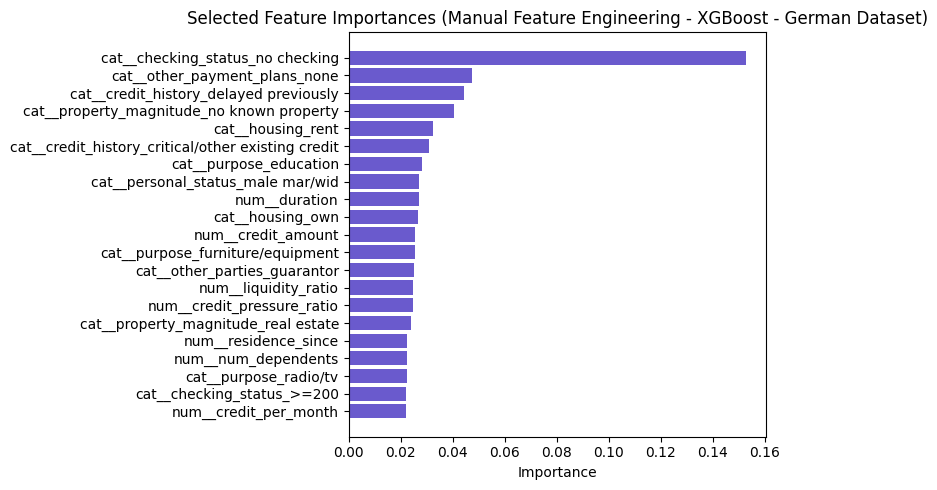

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#6A5ACD'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (Manual Feature Engineering - XGBoost - German Dataset)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [22]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[182  28]
 [ 40  50]]
classification_report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       210
           1       0.64      0.56      0.60        90

    accuracy                           0.77       300
   macro avg       0.73      0.71      0.72       300
weighted avg       0.77      0.77      0.77       300

Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.659872
ROC-AUC                 0.804815
Recall (Fraud)          0.555556
Precision (Fraud)       0.641026
F1-Score                0.595238
True Positives (TP)           50
False Negatives (FN)          40
dtype: object


In [23]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 21 out of 42
cat__checking_status_no checking                      0.238305
cat__checking_status_>=200                            0.063755
cat__credit_history_critical/other existing credit    0.061974
cat__property_magnitude_real estate                   0.057542
cat__checking_status_<0                               0.056388
cat__housing_own                                      0.055255
cat__purpose_new car                                  0.045353
cat__other_payment_plans_none                         0.044767
cat__purpose_education                                0.040373
num__installment_commitment                           0.036662
dtype: float32


In [24]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

                 Model         Method    PR-AUC   ROC-AUC  Recall (Fraud)  \
0  Logistic Regression  Class Weights  0.621282  0.773016        0.744444   
1  Logistic Regression          SMOTE  0.589835  0.779418        0.700000   
2        Random Forest  Class Weights  0.619266  0.789206        0.544444   
3        Random Forest          SMOTE  0.567376  0.786085        0.522222   
4              XGBoost  Class Weights  0.590421  0.758307        0.588889   
5              XGBoost          SMOTE  0.659872  0.804815        0.555556   

   Precision (Fraud)  F1-Score  True Positives (TP)  False Negatives (FN)  
0           0.496296  0.595556                   67                    23  
1           0.557522  0.620690                   63                    27  
2           0.583333  0.563218                   49                    41  
3           0.566265  0.543353                   47                    43  
4           0.524752  0.554974                   53                    37  
5   

In [25]:
for col in categorical_features:
    print(f"{col}: {data[col].unique().tolist()}")

checking_status: ['<0', '0<=X<200', 'no checking', '>=200']
credit_history: ['critical/other existing credit', 'existing paid', 'delayed previously', 'no credits/all paid', 'all paid']
purpose: ['radio/tv', 'education', 'furniture/equipment', 'new car', 'used car', 'business', 'domestic appliance', 'repairs', 'other', 'retraining']
personal_status: ['male single', 'female div/dep/mar', 'male div/sep', 'male mar/wid']
other_parties: ['none', 'guarantor', 'co applicant']
property_magnitude: ['real estate', 'life insurance', 'no known property', 'car']
other_payment_plans: ['none', 'bank', 'stores']
housing: ['own', 'for free', 'rent']
own_telephone: ['yes', 'none']
foreign_worker: ['yes', 'no']


Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

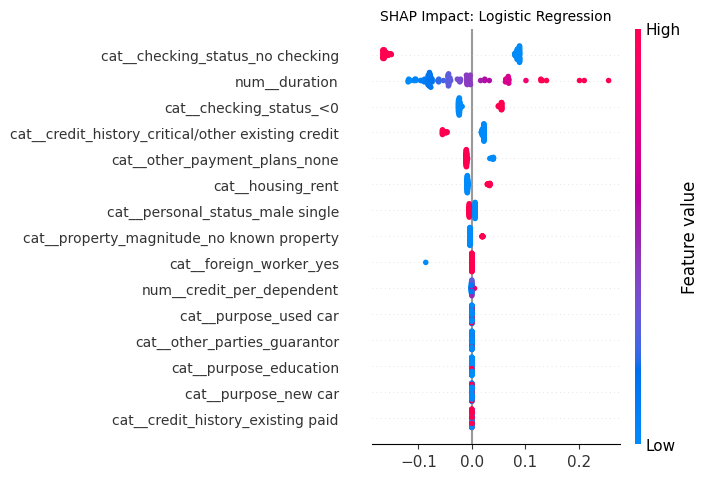

In [19]:
# --- LOGISTIC REGRESSION SHAP ---
import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

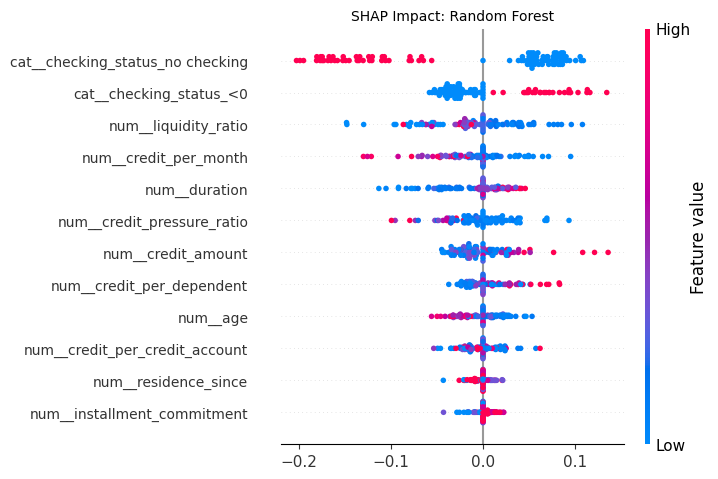

In [20]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

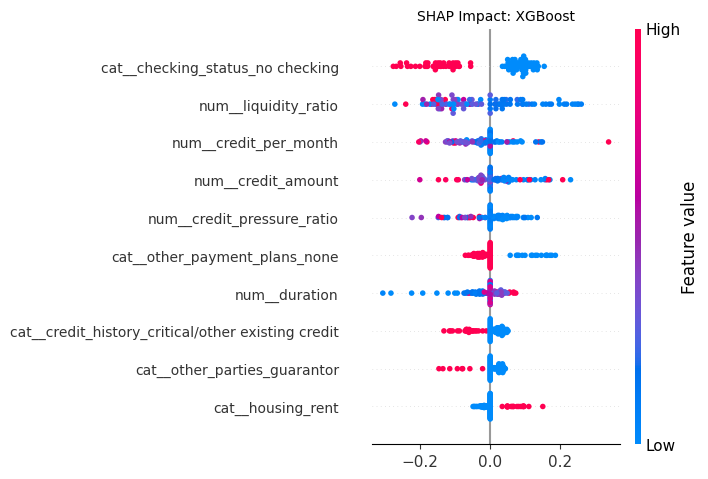

In [21]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()